# Lecture 15, Notebook 03: Structural estimation via SMM — Brock--Mirman, scalar persistence

This updated version keeps the demonstration deliberately compact.  The workflow is:

1. train one neural policy surrogate with the structural parameter \(\varrho\) as an input;
2. generate synthetic data at \(\varrho_{\mathrm{true}}=0.90\);
3. simulate the same surrogate for candidate values of \(\varrho\) under common random numbers;
4. estimate \(\varrho\) by minimizing a simple SMM criterion.

The GP moment-map and active-learning layer from the longer version is omitted here.  That layer is useful for research-scale bootstraps and high-dimensional search, but it obscures the basic estimation idea in a first pass.


In [1]:
SEED = 0

import numpy as np
import torch
try:
    torch.set_num_threads(2)
    torch.set_num_interop_threads(2)
except RuntimeError:
    # This only matters when a user reruns this cell inside an already-active kernel.
    pass
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
fig_dir = Path("fig")
fig_dir.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 12

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Inline figures enabled; optional figure directory: {fig_dir.resolve()}")


Using device: cpu
PyTorch version: 2.10.0+cpu
Inline figures enabled; optional figure directory: /mnt/data/fig


## 1. Model, quadrature, and the pseudo-state policy surrogate

The model is the partial-depreciation Brock--Mirman economy used in Chapter 10:
\[
Y_t = z_t K_t^\alpha, \qquad
K_{t+1} = (1-\delta)K_t + s_t Y_t, \qquad
C_t = (1-s_t)Y_t,
\]
with \(\log z_{t+1}=\varrho\log z_t + \sigma_z\varepsilon_{t+1}\).  The network learns
\[
(z_t,K_t,\varrho) \mapsto s_t \in (0,1).
\]

The short steady-state anchor below only fixes the economically relevant low-saving branch during classroom-scale training.  The Euler residual remains the training objective.


In [2]:
# Economic parameters.
alpha   = 0.36
delta   = 0.10
beta    = 0.96
sigma_z = 0.04

rho_lo, rho_hi = 0.50, 0.99
z_lo, z_hi     = 0.70, 1.30
k_lo, k_hi     = 0.50, 12.0

# Classroom training budget.
N_TRAIN = 400
BATCH_SIZE = 256
LEARNING_RATE = 5e-4

# Gauss-Hermite quadrature for E_t[.].
n_gh = 5
gh_nodes, gh_weights = np.polynomial.hermite.hermgauss(n_gh)
gh_weights = gh_weights / np.sqrt(np.pi)
gh_nodes   = gh_nodes * np.sqrt(2.0)

x_int = torch.tensor(gh_nodes * sigma_z, dtype=torch.float32, device=device)
w_gh  = torch.tensor(gh_weights, dtype=torch.float32, device=device)

# Deterministic steady state under z=1: 1 = beta * (1 - delta + alpha K^(alpha-1)).
k_star = (alpha / (1.0 / beta - 1.0 + delta)) ** (1.0 / (1.0 - alpha))
s_star = delta * k_star / (k_star ** alpha)
X_anchor = torch.tensor([[1.0, k_star, 0.90]], dtype=torch.float32, device=device)
s_anchor = torch.tensor([[s_star]], dtype=torch.float32, device=device)

print(f"Calibration: alpha={alpha}, delta={delta}, beta={beta}, sigma_z={sigma_z}")
print(f"rho range: [{rho_lo}, {rho_hi}]")
print(f"Steady-state anchor: K*={k_star:.3f}, s*={s_star:.3f}")
print(f"Gauss-Hermite weights sum to {gh_weights.sum():.6f}")


Calibration: alpha=0.36, delta=0.1, beta=0.96, sigma_z=0.04
rho range: [0.5, 0.99]
Steady-state anchor: K*=4.294, s*=0.254
Gauss-Hermite weights sum to 1.000000


In [3]:
class PolicyNet(nn.Module):
    """(z, K, rho) -> output-based savings rate s in (0,1)."""
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, 1), nn.Sigmoid(),
        )
        # Start near the economically relevant savings share.
        nn.init.zeros_(self.net[-2].weight)
        nn.init.constant_(self.net[-2].bias, np.log(0.25 / 0.75))

    def forward(self, x):
        return self.net(x)


def sample_states(n):
    z   = torch.rand(n, 1, device=device) * (z_hi   - z_lo)   + z_lo
    K   = torch.rand(n, 1, device=device) * (k_hi   - k_lo)   + k_lo
    rho = torch.rand(n, 1, device=device) * (rho_hi - rho_lo) + rho_lo
    return torch.cat([z, K, rho], dim=1)


def euler_loss(X, policy, anchor_weight=1e-3):
    z_t   = X[:, 0:1]
    K_t   = X[:, 1:2]
    rho_t = X[:, 2:3]

    Y_t   = z_t * K_t**alpha
    s_t   = policy(X)
    K_tp1 = (1.0 - delta) * K_t + Y_t * s_t
    C_t   = Y_t * (1.0 - s_t)

    expectation = torch.zeros_like(C_t)
    for j in range(n_gh):
        z_tp1 = torch.exp(rho_t * torch.log(z_t) + x_int[j])
        X_tp1 = torch.cat([z_tp1, K_tp1, rho_t], dim=1)
        Y_tp1 = z_tp1 * K_tp1**alpha
        s_tp1 = policy(X_tp1)
        C_tp1 = Y_tp1 * (1.0 - s_tp1)
        r_tp1 = alpha * z_tp1 * K_tp1**(alpha - 1.0)
        expectation = expectation + w_gh[j] * (1.0 - delta + r_tp1) / C_tp1

    relative_error = 1.0 / (beta * C_t * expectation) - 1.0
    loss = torch.mean(relative_error**2)
    loss = loss + anchor_weight * torch.mean((policy(X_anchor) - s_anchor)**2)
    return loss, relative_error


policy = PolicyNet().to(device)
optimizer = torch.optim.Adam(policy.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_TRAIN, eta_min=1e-5)

losses = []
for step in range(N_TRAIN):
    X = sample_states(BATCH_SIZE)
    loss, _ = euler_loss(X, policy)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    losses.append(float(loss.detach().cpu()))
    if (step + 1) % 200 == 0:
        with torch.no_grad():
            s_ss = float(policy(X_anchor).cpu())
        print(f"step {step+1:4d}/{N_TRAIN} | loss={losses[-1]:.3e} | s(z=1,K*,rho=.90)={s_ss:.4f}")

policy.eval()
print(f"Final Euler-plus-anchor loss: {losses[-1]:.3e}")
print(f"Policy network parameters: {sum(p.numel() for p in policy.parameters()):,}")


step  200/400 | loss=1.694e-03 | s(z=1,K*,rho=.90)=0.2893
step  400/400 | loss=1.301e-03 | s(z=1,K*,rho=.90)=0.2623
Final Euler-plus-anchor loss: 1.301e-03
Policy network parameters: 4,481


## 2. Inspect the trained policy family

The figure shows the whole pseudo-state surrogate at \(z=1\).  The network is trained once over the entire \((K,\varrho)\) rectangle and is then reused inside the estimator.


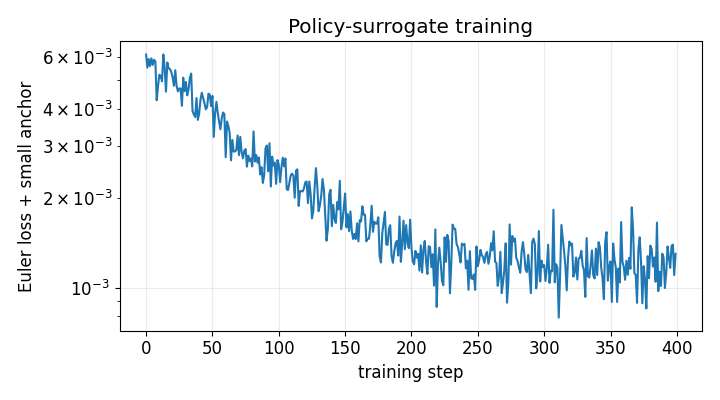

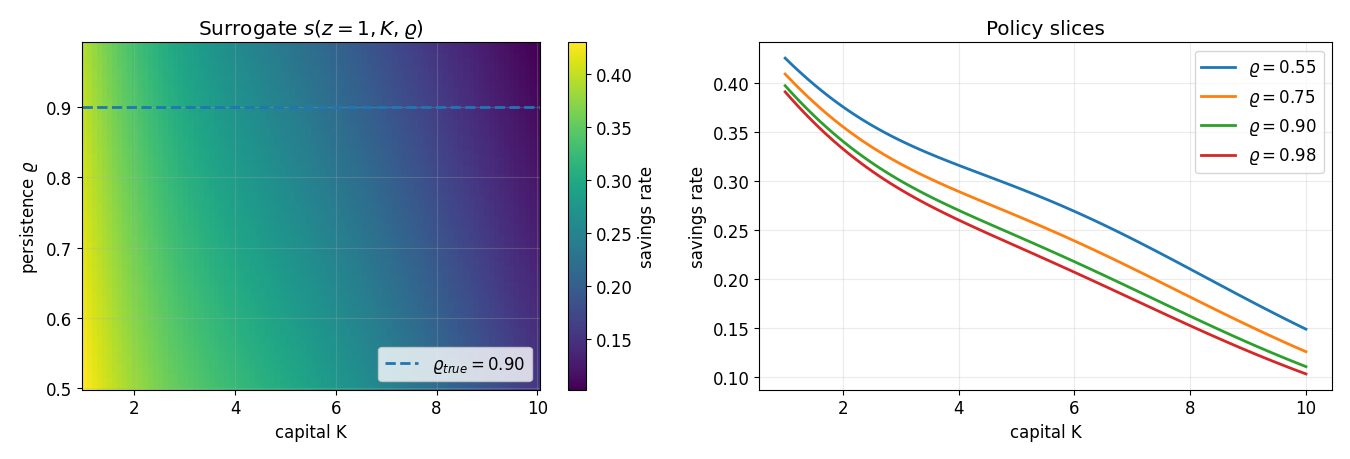

In [4]:
# Training loss.
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.semilogy(losses)
ax.set_xlabel("training step")
ax.set_ylabel("Euler loss + small anchor")
ax.set_title("Policy-surrogate training")
plt.tight_layout()

# Surrogate heatmap and policy slices.
n_K, n_rho = 90, 90
K_lin   = np.linspace(1.0, 10.0, n_K)
rho_lin = np.linspace(rho_lo, rho_hi, n_rho)
KK, RR  = np.meshgrid(K_lin, rho_lin, indexing="xy")
X_eval = torch.tensor(
    np.column_stack([np.ones(KK.size), KK.ravel(), RR.ravel()]),
    dtype=torch.float32, device=device,
)
with torch.no_grad():
    S = policy(X_eval).cpu().numpy().reshape(KK.shape)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
ax = axes[0]
im = ax.pcolormesh(KK, RR, S, shading="auto")
ax.axhline(0.90, linestyle="--", linewidth=2, label=r"$\varrho_{true}=0.90$")
ax.set_xlabel("capital K")
ax.set_ylabel(r"persistence $\varrho$")
ax.set_title(r"Surrogate $s(z=1,K,\varrho)$")
ax.legend(loc="lower right")
plt.colorbar(im, ax=ax, label="savings rate")

ax = axes[1]
for rho_val in [0.55, 0.75, 0.90, 0.98]:
    X_slice = torch.tensor(
        np.column_stack([np.ones_like(K_lin), K_lin, np.full_like(K_lin, rho_val)]),
        dtype=torch.float32, device=device,
    )
    with torch.no_grad():
        s_slice = policy(X_slice).cpu().numpy().ravel()
    ax.plot(K_lin, s_slice, linewidth=2, label=fr"$\varrho={rho_val:.2f}$")
ax.set_xlabel("capital K")
ax.set_ylabel("savings rate")
ax.set_title("Policy slices")
ax.legend()
plt.tight_layout()


## 3. Synthetic data, common random numbers, and moments

The synthetic data are generated at \(\varrho_{true}=0.90\).  Every candidate \(\varrho\) is evaluated using the same initial condition, burn-in, horizon, and shock sequence.  These common random numbers make the SMM criterion deterministic and smooth.


In [5]:
T_BURN = 100
T_SIM  = 600
rho_true = 0.90
rho_grid = np.round(np.arange(rho_lo, rho_hi + 1e-10, 0.005), 4)


def simulate_many_rho(policy, rho_values, T_burn=T_BURN, T_sim=T_SIM, seed=SEED + 123, K0=3.0):
    """Vectorized simulation for many candidate rho values under one common shock path."""
    torch.manual_seed(seed)
    rho_values = np.asarray(rho_values, dtype=np.float32)
    n = len(rho_values)
    T = T_burn + T_sim

    rho = torch.tensor(rho_values.reshape(-1, 1), dtype=torch.float32, device=device)
    z_t = torch.ones(n, 1, device=device)
    K_t = torch.full((n, 1), float(K0), dtype=torch.float32, device=device)
    shocks = torch.randn(T, 1, device=device)

    C_all, I_all, Y_all = [], [], []
    with torch.no_grad():
        for t in range(T):
            X_t = torch.cat([z_t, K_t, rho], dim=1)
            s_t = policy(X_t)
            Y_t = z_t * K_t**alpha
            I_t = Y_t * s_t
            C_t = Y_t * (1.0 - s_t)
            K_tp1 = (1.0 - delta) * K_t + I_t
            z_tp1 = torch.exp(rho * torch.log(z_t) + sigma_z * shocks[t])
            if t >= T_burn:
                C_all.append(C_t.squeeze(1).cpu().numpy())
                I_all.append(I_t.squeeze(1).cpu().numpy())
                Y_all.append(Y_t.squeeze(1).cpu().numpy())
            z_t, K_t = z_tp1, K_tp1
    return np.stack(C_all), np.stack(I_all), np.stack(Y_all)


def autocorr_columns(X):
    x0 = X[:-1] - X[:-1].mean(axis=0)
    x1 = X[1:]  - X[1:].mean(axis=0)
    denom = np.sqrt((x0 * x0).sum(axis=0) * (x1 * x1).sum(axis=0))
    return (x0 * x1).sum(axis=0) / denom


def compute_moments_many(C, I, Y):
    dlog_C = np.diff(np.log(C), axis=0)
    log_Y  = np.log(Y)
    return np.column_stack([
        np.std(dlog_C, axis=0),
        autocorr_columns(dlog_C),
        autocorr_columns(log_Y),
        np.mean(I / Y, axis=0),
    ])

moment_names = [
    r"Std($\Delta\log C$)",
    r"Autocorr($\Delta\log C$)",
    r"Autocorr($\log Y$)",
    "Mean savings rate",
]
used = np.array([True, True, True, False])

C_grid, I_grid, Y_grid = simulate_many_rho(policy, rho_grid)
moments_grid = compute_moments_many(C_grid, I_grid, Y_grid)
idx_true = int(np.where(np.isclose(rho_grid, rho_true))[0][0])
target_moments = moments_grid[idx_true].copy()

print(f"Candidate grid size: {len(rho_grid)}")
print(f"Synthetic sample length after burn-in: {T_SIM}")
print(f"rho_true = {rho_true:.2f}")
print("\nTarget moments:")
for name, value, is_used in zip(moment_names, target_moments, used):
    tag = "used" if is_used else "diagnostic only"
    print(f"  {name:<32s}: {value:+.6f}  ({tag})")


Candidate grid size: 99
Synthetic sample length after burn-in: 600
rho_true = 0.90

Target moments:
  Std($\Delta\log C$)             : +0.021258  (used)
  Autocorr($\Delta\log C$)        : +0.203289  (used)
  Autocorr($\log Y$)              : +0.962467  (used)
  Mean savings rate               : +0.259095  (diagnostic only)


For the AR(1) shock, Std(Delta log z) = sigma_z * sqrt(2/(1+rho)).
  rho=0.50: 0.0462
  rho=0.99: 0.0401
The level variance, by contrast, is sigma_z^2/(1-rho^2).


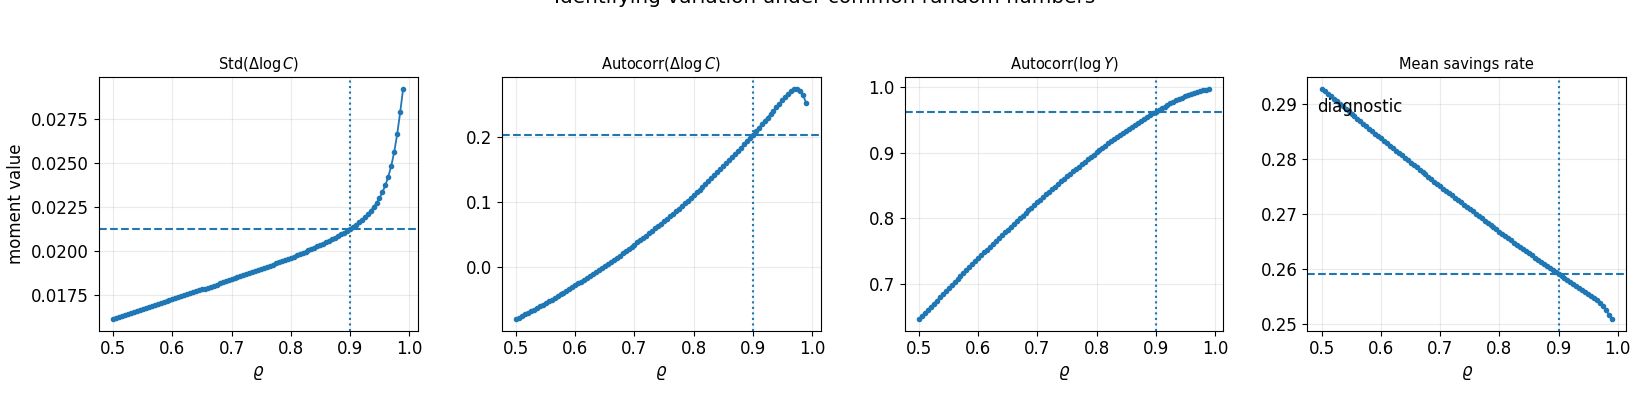

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16.5, 4.0))
for j, (ax, name) in enumerate(zip(axes, moment_names)):
    ax.plot(rho_grid, moments_grid[:, j], marker="o", markersize=3, linewidth=1.3)
    ax.axhline(target_moments[j], linestyle="--", linewidth=1.5)
    ax.axvline(rho_true, linestyle=":", linewidth=1.5)
    ax.set_xlabel(r"$\varrho$")
    ax.set_title(name, fontsize=10.5)
    if j == 0:
        ax.set_ylabel("moment value")
    if not used[j]:
        ax.text(0.03, 0.92, "diagnostic", transform=ax.transAxes, va="top")
plt.suptitle(r"Identifying variation under common random numbers", y=1.03)
plt.tight_layout()

# Correct AR(1) benchmark for first differences of log productivity.
std_dlogz = sigma_z * np.sqrt(2.0 / (1.0 + rho_grid))
print("For the AR(1) shock, Std(Delta log z) = sigma_z * sqrt(2/(1+rho)).")
print(f"  rho={rho_grid[0]:.2f}: {std_dlogz[0]:.4f}")
print(f"  rho={rho_grid[-1]:.2f}: {std_dlogz[-1]:.4f}")
print("The level variance, by contrast, is sigma_z^2/(1-rho^2).")


## 4. SMM estimation

The SMM criterion uses the three dynamic moments and identity weighting:
\[
Q(\varrho) = \left[m(\varrho)-\widehat m^{data}\right]'\left[m(\varrho)-\widehat m^{data}\right].
\]
The fourth moment, the mean savings rate, is displayed as a diagnostic but is not used for scalar persistence estimation.


In [7]:
diff = moments_grid[:, used] - target_moments[used]
Q = np.sum(diff * diff, axis=1)
idx_hat = int(np.argmin(Q))
rho_hat = float(rho_grid[idx_hat])
fitted_moments = moments_grid[idx_hat]

print(f"Grid SMM estimate rho_hat = {rho_hat:.4f}")
print(f"rho_true                  = {rho_true:.4f}")
print(f"absolute error            = {abs(rho_hat - rho_true):.4e}")
print(f"Q(rho_hat)                = {Q[idx_hat]:.4e}")
print(f"interior solution         = {rho_lo < rho_hat < rho_hi}")

print("\nMatched moments at rho_hat")
print("-" * 78)
print(f"{'moment':<32s} {'target':>12s} {'fit':>12s} {'diff':>12s} {'used':>8s}")
print("-" * 78)
for name, target, fit, is_used in zip(moment_names, target_moments, fitted_moments, used):
    print(f"{name:<32s} {target:>+12.6f} {fit:>+12.6f} {fit-target:>+12.2e} {str(bool(is_used)):>8s}")
print("-" * 78)


Grid SMM estimate rho_hat = 0.9000
rho_true                  = 0.9000
absolute error            = 0.0000e+00
Q(rho_hat)                = 0.0000e+00
interior solution         = True

Matched moments at rho_hat
------------------------------------------------------------------------------
moment                                 target          fit         diff     used
------------------------------------------------------------------------------
Std($\Delta\log C$)                 +0.021258    +0.021258    +0.00e+00     True
Autocorr($\Delta\log C$)            +0.203289    +0.203289    +0.00e+00     True
Autocorr($\log Y$)                  +0.962467    +0.962467    +0.00e+00     True
Mean savings rate                   +0.259095    +0.259095    +0.00e+00    False
------------------------------------------------------------------------------


In [8]:
# Finite-difference moment sensitivity at the truth, using the precomputed grid.
step = rho_grid[1] - rho_grid[0]
dm_drho = (moments_grid[idx_true + 1] - moments_grid[idx_true - 1]) / (2.0 * step)

print("Finite-difference dm/drho at rho_true")
for name, slope, is_used in zip(moment_names, dm_drho, used):
    tag = "used" if is_used else "diagnostic"
    print(f"  {name:<32s}: {slope:+.4e}  ({tag})")
print(f"\nNorm over identifying moments: {np.linalg.norm(dm_drho[used]):.4e}")


Finite-difference dm/drho at rho_true
  Std($\Delta\log C$)             : +2.2397e-02  (used)
  Autocorr($\Delta\log C$)        : +1.0194e+00  (used)
  Autocorr($\log Y$)              : +5.3061e-01  (used)
  Mean savings rate               : -7.3600e-02  (diagnostic)

Norm over identifying moments: 1.1495e+00


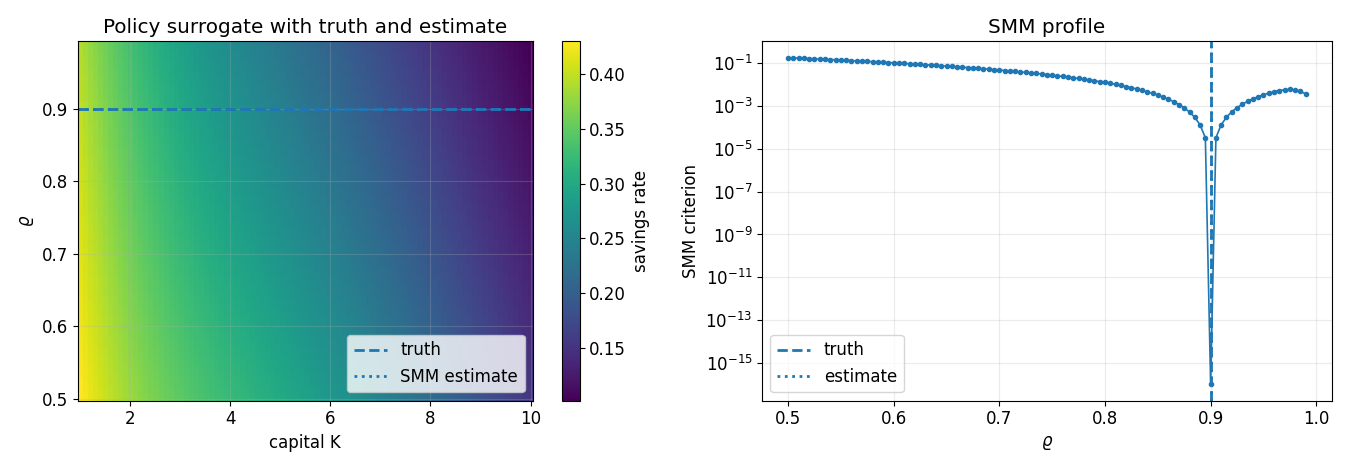

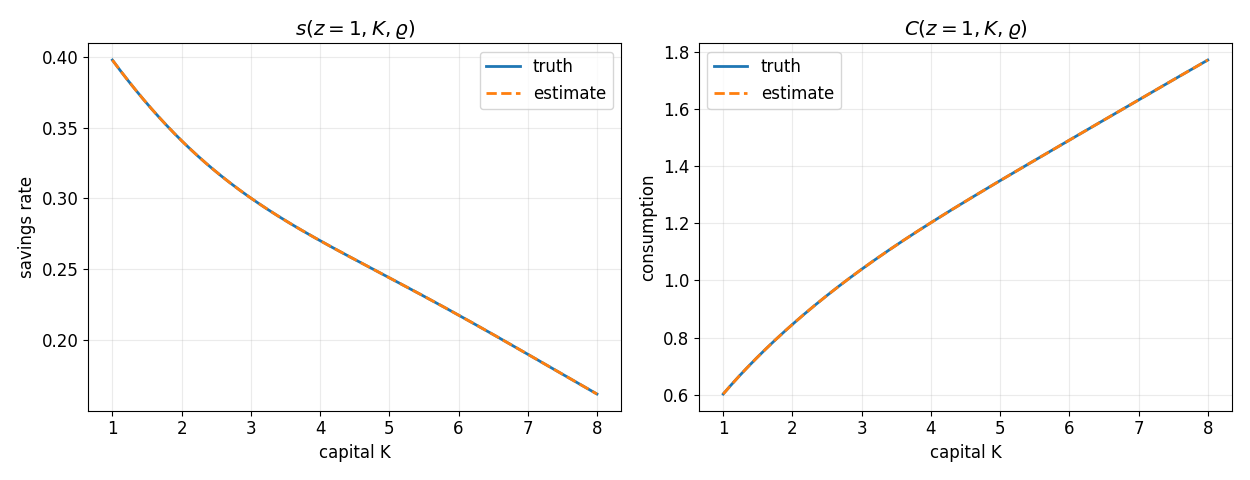

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.7))

ax = axes[0]
im = ax.pcolormesh(KK, RR, S, shading="auto")
ax.axhline(rho_true, linestyle="--", linewidth=2, label=r"truth")
ax.axhline(rho_hat,  linestyle=":",  linewidth=2, label=r"SMM estimate")
ax.set_xlabel("capital K")
ax.set_ylabel(r"$\varrho$")
ax.set_title(r"Policy surrogate with truth and estimate")
ax.legend(loc="lower right")
plt.colorbar(im, ax=ax, label="savings rate")

ax = axes[1]
ax.plot(rho_grid, np.maximum(Q, 1e-16), marker="o", markersize=3, linewidth=1.2)
ax.axvline(rho_true, linestyle="--", linewidth=2, label=r"truth")
ax.axvline(rho_hat,  linestyle=":",  linewidth=2, label=r"estimate")
ax.set_xlabel(r"$\varrho$")
ax.set_ylabel("SMM criterion")
ax.set_yscale("log")
ax.set_title("SMM profile")
ax.legend()
plt.tight_layout()

# Policy and consumption curves at truth and estimate.
K_plot = np.linspace(1.0, 8.0, 250)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for label, rho_val, style in [("truth", rho_true, "-"), ("estimate", rho_hat, "--")]:
    X_plot = torch.tensor(
        np.column_stack([np.ones_like(K_plot), K_plot, np.full_like(K_plot, rho_val)]),
        dtype=torch.float32, device=device,
    )
    with torch.no_grad():
        s_plot = policy(X_plot).cpu().numpy().ravel()
    Y_plot = K_plot**alpha
    C_plot = (1.0 - s_plot) * Y_plot
    axes[0].plot(K_plot, s_plot, linestyle=style, linewidth=2, label=label)
    axes[1].plot(K_plot, C_plot, linestyle=style, linewidth=2, label=label)

axes[0].set_xlabel("capital K")
axes[0].set_ylabel("savings rate")
axes[0].set_title(r"$s(z=1,K,\varrho)$")
axes[0].legend()
axes[1].set_xlabel("capital K")
axes[1].set_ylabel("consumption")
axes[1].set_title(r"$C(z=1,K,\varrho)$")
axes[1].legend()
plt.tight_layout()


## Summary

The scalar notebook now contains only the core teaching pipeline:

- one pseudo-state policy surrogate is trained over \(\varrho\in[0.50,0.99]\);
- synthetic data are generated at \(\varrho_{true}=0.90\);
- common random numbers turn the simulated moment map into a deterministic function of \(\varrho\);
- the SMM profile has a clear interior minimum and recovers the synthetic truth.

This is the simplest useful classroom demonstration.  The GP moment-map layer can be reintroduced later as an optional extension once students understand the surrogate-SMM estimator itself.


In [10]:
assert abs(rho_hat - rho_true) <= 0.005 + 1e-12
assert rho_lo < rho_hat < rho_hi
print("Validation passed: scalar SMM recovers the synthetic persistence parameter.")


Validation passed: scalar SMM recovers the synthetic persistence parameter.
